In [115]:
import pandas as pd
import numpy as np

import time
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

### Data Prep

In [131]:
files = [
    "../data/processed/process_ENG1.csv",
    # "../data/processed/process_FRA1.csv",
    # "../data/processed/process_GER1.csv",
    # "../data/processed/process_ITA1.csv",
    # "../data/processed/process_SPA1.csv",
]

In [132]:
dfs = []

for f in files:
    dfs.append(pd.read_csv(f))

matches_df = pd.concat(dfs, ignore_index=True)
# matches_df = matches_df.dropna()

## BREAK

In [78]:
file = "../data/processed/temp.csv"
my_df = pd.read_csv(file)
# Get arsenal matches only
arsenal_matches = my_df[(my_df["team"] == "Arsenal")]
my_cols = [x for x in arsenal_matches.columns if "szn_" in x or x in ["date", "team", "opponent", "gf", "ga"]]

C:\Users\negia\AppData\Local\Temp\ipykernel_18848\310612304.py:2: DtypeWarning: Columns (0,1,2,4,5,6,7,8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  my_df = pd.read_csv(file)


In [79]:
arsenal_matches[["date", "team", "opponent", "gf", "ga", "win", "szn_wins_last5"]].sort_values(by="date").head(20)

,date,team,opponent,gf,ga,win,szn_wins_last5
0,2022-08-20,Arsenal,Bournemouth,3.0,0.0,1.0,0.0
1,2022-08-27,Arsenal,Fulham,2.0,1.0,1.0,NaN
2,2022-08-31,Arsenal,Aston Villa,2.0,1.0,1.0,NaN
3,2022-09-04,Arsenal,Manchester Utd,1.0,3.0,0.0,NaN
4,2022-09-18,Arsenal,Brentford,3.0,0.0,1.0,NaN
5,2022-10-01,Arsenal,Tottenham,3.0,1.0,1.0,NaN
6,2022-10-09,Arsenal,Liverpool,3.0,2.0,1.0,NaN
7,2022-10-16,Arsenal,Leeds United,1.0,0.0,1.0,NaN
8,2022-10-23,Arsenal,Southampton,1.0,1.0,0.0,NaN
9,2022-10-30,Arsenal,Nottingham Forest,5.0,0.0,1.0,NaN


In [35]:
# Get cumulative stats for 2025 season arsenal (home and away)
arsenal_2025_home = matches_df[(matches_df["season"] == 2023) & (matches_df["home_team"] == "Arsenal")]
arsenal_2025_away = matches_df[(matches_df["season"] == 2024) & (matches_df["away_team"] == "Arsenal")]
arsenal_2025 = matches_df[((matches_df["season"] ==  2023) & (matches_df["home_team"] == "Arsenal")) | ((matches_df["season"] == 2023) & (matches_df["away_team"] == "Arsenal"))]

In [37]:
arsenal_2025[["date", "home_team", "away_team", "gf_forHomeTeam", "gf_forAwayTeam", "szn_win_pct_forHomeTeam", "szn_win_pct_rolling_forHomeTeam"]].sort_values(by="date")

,date,home_team,away_team,gf_forHomeTeam,gf_forAwayTeam,szn_win_pct_forHomeTeam,szn_win_pct_rolling_forHomeTeam
0,2023-08-12,Arsenal,Nottingham Forest,2.0,1.0,0.000000,0.679100
14,2023-08-21,Crystal Palace,Arsenal,0.0,1.0,1.000000,0.313336
17,2023-08-26,Arsenal,Fulham,2.0,2.0,1.000000,0.757646
33,2023-09-03,Arsenal,Manchester Utd,3.0,1.0,0.666667,0.833403
42,2023-09-17,Everton,Arsenal,0.0,1.0,0.000000,0.050000
48,2023-09-24,Arsenal,Tottenham,2.0,2.0,0.800000,0.854167
54,2023-09-30,Bournemouth,Arsenal,0.0,4.0,0.000000,0.000000
73,2023-10-08,Arsenal,Manchester City,1.0,0.0,0.714286,0.776667
80,2023-10-21,Chelsea,Arsenal,2.0,2.0,0.375000,0.247143
86,2023-10-28,Arsenal,Sheffield Utd,5.0,0.0,0.666667,0.736190


## BREAK

In [133]:
matches_df["xg_rolling_diff"] = abs(matches_df["xg_rolling_forHomeTeam"] - matches_df["xg_rolling_forAwayTeam"])
matches_df["xg_mean_diff"] = abs(matches_df["xg_mean_forHomeTeam"] - matches_df["xg_mean_forAwayTeam"])
matches_df["xa_rolling_diff"] = abs(matches_df["xa_rolling_forHomeTeam"] - matches_df["xa_rolling_forAwayTeam"])
matches_df["xa_mean_diff"] = abs(matches_df["xa_mean_forHomeTeam"] - matches_df["xa_mean_forAwayTeam"])
matches_df["xga_rolling_diff"] = abs(matches_df["xga_rolling_forHomeTeam"] - matches_df["xga_rolling_forAwayTeam"])
matches_df["xga_mean_diff"] = abs(matches_df["xga_mean_forHomeTeam"] - matches_df["xga_mean_forAwayTeam"])
matches_df["gf_rolling_diff"] = abs(matches_df["gf_rolling_forHomeTeam"] - matches_df["gf_rolling_forAwayTeam"])
matches_df["gf_mean_diff"] = abs(matches_df["gf_mean_forHomeTeam"] - matches_df["gf_mean_forAwayTeam"])
matches_df["ga_rolling_diff"] = abs(matches_df["ga_rolling_forHomeTeam"] - matches_df["ga_rolling_forAwayTeam"])
matches_df["ga_mean_diff"] = abs(matches_df["ga_mean_forHomeTeam"] - matches_df["ga_mean_forAwayTeam"])


In [134]:
def get_predictors_basic():
    general = ["venue_code", "team_code", "day_code", "promoted", "days_since_last_game", "is_first_game"]
    attacking = ["gf", "xg", "sh", "sot", "npxg", "npxg_per_sh"]
    defense = ["int", "xga", "ga"]
    gk = ["sota", "saves", "save_pct", "psxg"]

    # add features relating to season performance (cum_pts), and result percentages (win_pct, draw_pct, loss_pct)

    base = attacking + defense + gk

    home_stats = [f"{x}_atHome_rolling" for x in base] + [f"{x}_atHome_mean" for x in base]
    away_stats = [f"{x}_atAway_rolling" for x in base] + [f"{x}_atAway_mean" for x in base]

    home_stats = [f"{x}_forHomeTeam" for x in home_stats] + [f"{x}_forAwayTeam" for x in home_stats]
    away_stats = [f"{x}_forHomeTeam" for x in away_stats] + [f"{x}_forAwayTeam" for x in away_stats]

    # Stats regardless of home/away
    overall_home = [f"{x}_rolling_forHomeTeam" for x in base] + [f"{x}_mean_forHomeTeam" for x in base]
    overall_away = [f"{x}_rolling_forAwayTeam" for x in base] + [f"{x}_mean_forAwayTeam" for x in base]

    # Seasonal performance stats
    szn_perf = ["szn_cum_pts", "szn_win_pct", "szn_draw_pct", "szn_loss_pct"]
    
    szn_perf_home_away = [f"{x}_atHome" for x in szn_perf] + [f"{x}_atAway" for x in szn_perf]
    szn_perf_final = szn_perf + szn_perf_home_away
    szn_perf_final = [f"{x}_forHomeTeam" for x in szn_perf_final] + [f"{x}_forAwayTeam" for x in szn_perf_final]


    predictors = [f"{x}_forHomeTeam" for x in general] + [f"{x}_forAwayTeam" for x in general] + home_stats + away_stats + overall_home + overall_away + szn_perf_final

    # Remove all predicotrs that contain forHomeTeam and atAway or forAwayTeam and atHome
    predictors = [col for col in predictors if not (("forHomeTeam" in col and "atAway" in col) or ("forAwayTeam" in col and "atHome" in col))]
    
    return predictors

In [135]:
cols = [
    "xg_rolling_diff",
    "xg_mean_diff",
    "xa_rolling_diff",
    "xa_mean_diff",
    "xga_rolling_diff",
    "xga_mean_diff",
    "gf_rolling_diff",
    "gf_mean_diff",
    "ga_rolling_diff",
    "ga_mean_diff"
] + get_predictors_basic()

In [136]:
X = matches_df[cols]
y = matches_df["result_code"]
y_one_hot = OneHotEncoder().fit_transform(y.values.reshape(-1, 1)).toarray()

### General Feature Selection

#### Removing Corrrelated Features

In [122]:
corr_matrix = matches_df[cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
matches_dropped = matches_df.drop(columns=to_drop)

In [123]:
len(list(corr_matrix.columns))
corr_matrix.to_csv("corr_matrix.csv")

In [124]:
# count how many times aeriallost_rolling_home is in the upper columns
print("All columns: ", len(cols))
print("Dropped columns: ", len(to_drop))
print("Remaining columns supposedly: ", len(cols) - len(to_drop))
print("Remaining columns actually: ", len(matches_df[cols].drop(columns=to_drop).columns))

All columns:  142
Dropped columns:  17
Remaining columns supposedly:  125
Remaining columns actually:  125


#### Feature Importance Using Simple Regression

In [137]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_one_hot = OneHotEncoder().fit_transform(y.values.reshape(-1, 1)).toarray()
y_std = scaler.fit_transform(y_one_hot)

N = X_scaled.shape[0]
w = np.dot(X_scaled.T, y_one_hot) / N

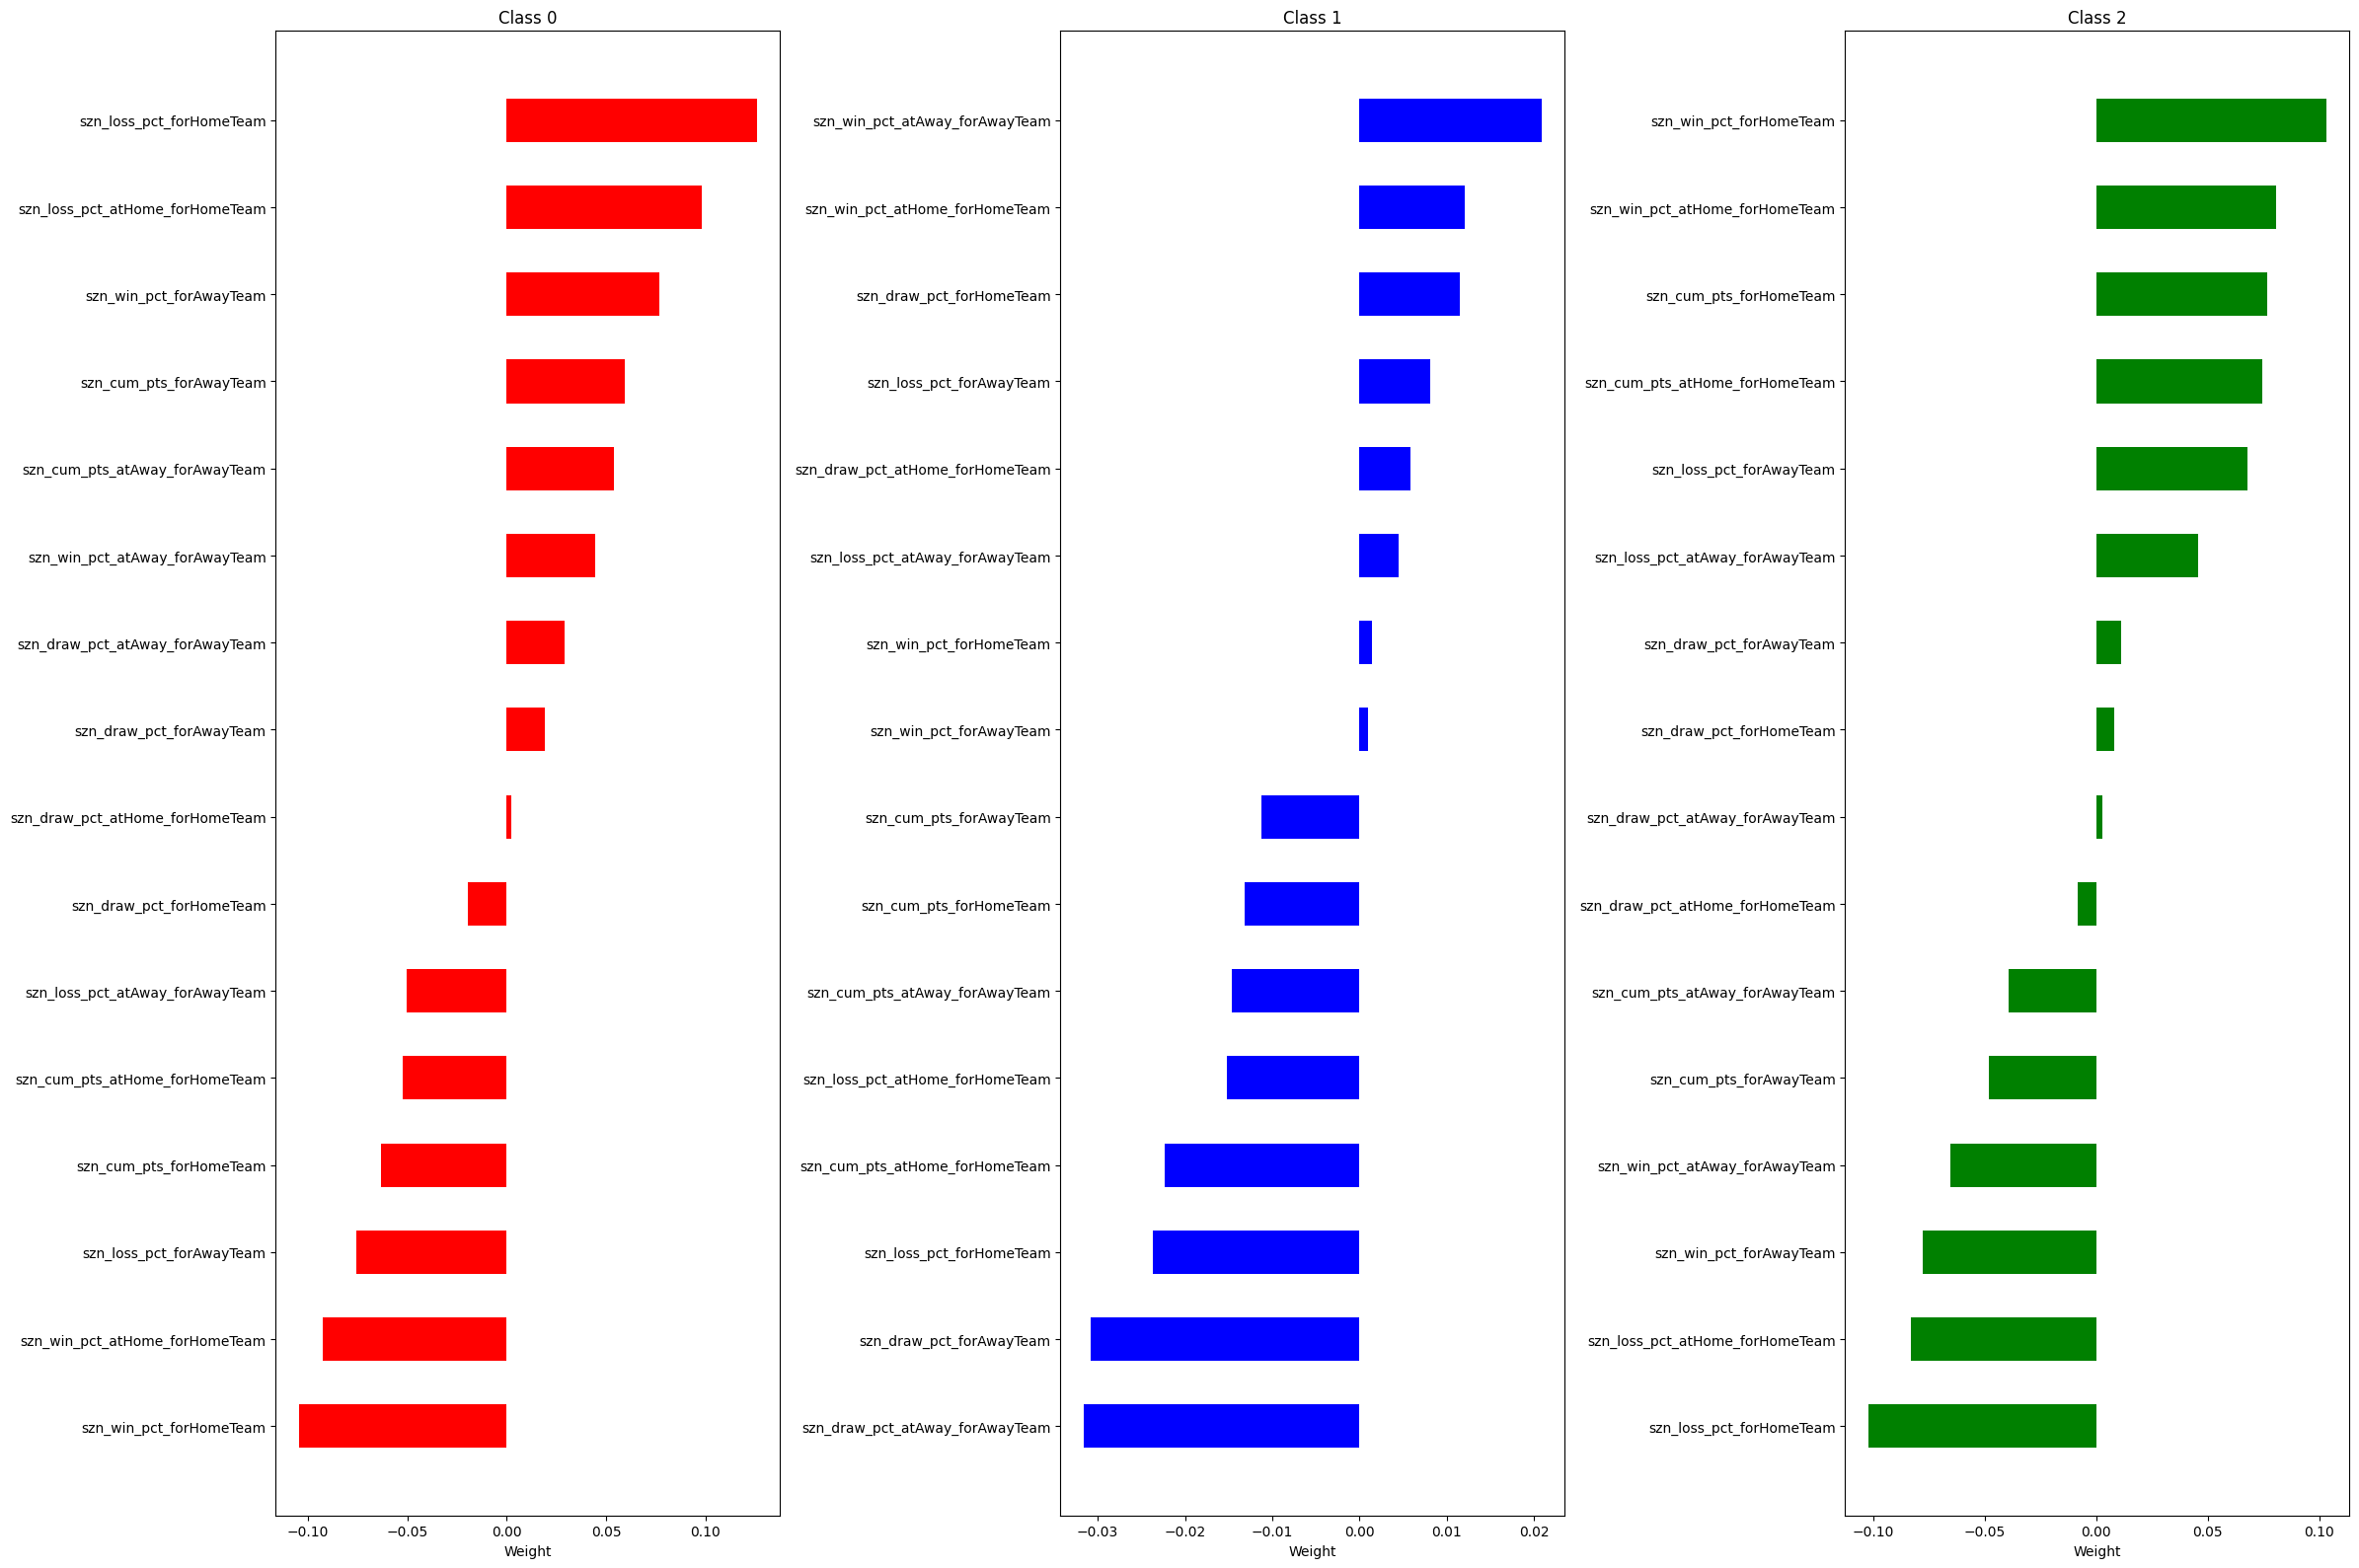

In [138]:
D, C = w.shape

fig, axes = plt.subplots(1, C, figsize=(24, 16))

colors = ["red", "blue", "green"]

feature_importances = dict()

for c in range(C):
    ax = axes[c]

    w_class = w[:, c]

    # sort the weights
    sorted_indices = np.argsort(w_class)[::-1]
    sorted_w = w_class[sorted_indices]
    sorted_features = X.columns[sorted_indices]

    # if c != 1:
    #     # Only keep rel_cols features
    #     rel_cols_indices = [i for i, feature in enumerate(sorted_features) if feature in rel_cols]
    #     rel_cols_sorted_indices = sorted_indices[rel_cols_indices]
    #     rel_cols_sorted_w = sorted_w[rel_cols_indices]
    #     rel_cols_sorted_features = sorted_features[rel_cols_indices]

    #     # Plot features
    #     ax.barh(rel_cols_sorted_features, rel_cols_sorted_w, color=colors[c], height=0.5)
    #     ax.set_title(f"Class {c}")
    #     ax.set_xlabel("Weight")
    #     ax.invert_yaxis()
    # else:
    #     # take top 25 and bottom 25 features and weights
    #     selected_features = np.concatenate([sorted_features[:25], sorted_features[-25:]])
    #     selected_w = np.concatenate([sorted_w[:25], sorted_w[-25:]])
        
    #     # Create horizontal bar plot
    #     ax.barh(selected_features, selected_w, color=colors[c], height=0.5)
    #     ax.set_title(f"Class {c}")
    #     ax.set_xlabel("Weight")
    #     ax.invert_yaxis()

    # Only keep rel_cols features
    # rel_cols_indices = [i for i, feature in enumerate(sorted_features) if feature in rel_cols]
    rel_cols_indices = [i for i, feature in enumerate(sorted_features) if "win_pct" in feature or "draw_pct" in feature or "loss_pct" in feature or "cum_pts" in feature]
    rel_cols_sorted_indices = sorted_indices[rel_cols_indices]
    rel_cols_sorted_w = sorted_w[rel_cols_indices]
    rel_cols_sorted_features = sorted_features[rel_cols_indices]

    # Plot features
    ax.barh(rel_cols_sorted_features, rel_cols_sorted_w, color=colors[c], height=0.5)
    ax.set_title(f"Class {c}")
    ax.set_xlabel("Weight")
    ax.invert_yaxis()

    # # take top 25 and bottom 25 features and weights
    # selected_features = np.concatenate([sorted_features[:25], sorted_features[-25:]])
    # selected_w = np.concatenate([sorted_w[:25], sorted_w[-25:]])
        
    # # Create horizontal bar plot
    # ax.barh(selected_features, selected_w, color=colors[c], height=0.5)
    # ax.set_title(f"Class {c}")
    # ax.set_xlabel("Weight")
    # ax.invert_yaxis()
    # ax.set_xlim(-0.15, 0.15)


    for feat, coef in zip(sorted_features, sorted_w):
        if feat in feature_importances:
            feature_importances[feat].append(coef)
        else:
            feature_importances[feat] = [coef]

plt.tight_layout()
plt.show()

In [33]:
# Mean absolute feature importance
mean_fi = {feat: np.mean([abs(x) for x in coefs]) for feat, coefs in feature_importances.items()}
sorted_mean_fi = sorted(mean_fi.items(), key=lambda x: x[1], reverse=True)

# Feature importance variability
var_fi = {feat: np.std([abs(x) for x in coefs]) for feat, coefs in feature_importances.items()}
sorted_var_fi = sorted(var_fi.items(), key=lambda x: x[1], reverse=True)

mean_mean_fi = np.mean([i for i in mean_fi.values()])
mean_var_fi = np.mean([i for i in var_fi.values()])

selected_features = [feat for feat, _ in mean_fi.items() if mean_fi[feat] > mean_mean_fi and var_fi[feat] > mean_var_fi]

#### Try on RF and XGBC

In [139]:
# dummy_features = ["venue_code", "team_code", "day_code", "promoted", "gf_rolling", "ga_rolling", "xg_mean", "xg_rolling", "xga_mean", "xga_rolling"]
# dummy_features = [col + "_home" for col in dummy_features] + [col + "_away" for col in dummy_features]

features = get_predictors_basic()
# matches_df_X = matches_df[cols]
# matches_df_X = matches_df[list(set(dummy_features + rel_cols))]
# matches_df_X = matches_df[list(set(selected_features + dummy_features + rel_cols))]
matches_df_X = matches_df[features]
labels = np.array([0, 1, 2])
targets = np.array(["Away Win", "Draw", "Home Win"])

In [140]:
model_RF = RandomForestClassifier(n_estimators=2400, class_weight='balanced', random_state=42)
model_XGB = XGBClassifier(n_estimators=4000, random_state=42)

scaler_RF = StandardScaler()

X_RF = matches_df_X

X_RF_scaled = scaler_RF.fit_transform(X_RF)

X_train, X_test, y_train, y_test = train_test_split(X_RF_scaled, y_one_hot, test_size=0.25, random_state=42)

In [141]:
model_RF.fit(X_train, y_train)
model_XGB.fit(X_train, y_train)

y_pred_RF = model_RF.predict(X_test)
y_pred_XGB = model_XGB.predict(X_test)

y_pred_RF = np.argmax(y_pred_RF, axis=1)
y_pred_XGB = np.argmax(y_pred_XGB, axis=1)

y_test_res = np.argmax(y_test, axis=1)

rf_report = classification_report(y_test_res, y_pred_RF, zero_division=0, labels=labels, target_names=targets, output_dict=True)
xgb_report = classification_report(y_test_res, y_pred_XGB, zero_division=0, labels=labels, target_names=targets, output_dict=True)

#### Try on Multinomial

In [142]:
scaler_mc = StandardScaler()

features = get_predictors_basic()

X_mc = matches_df_X

X_mc_scaled = scaler_mc.fit_transform(X_mc)
X_train, X_test, y_train, y_test = train_test_split(X_mc_scaled, y_one_hot, test_size=0.25, random_state=42)
y_train_1v1 = np.argmax(y_train, axis=1)

In [143]:
model_1vR = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=1000))
model_1vR.fit(X_train, y_train)
y_pred_MC_1vR = model_1vR.predict(X_test)
y_pred_MC_1vR = np.argmax(y_pred_MC_1vR, axis=1)
y_pred_test = np.argmax(y_test, axis=1)

mc_1vR_report = classification_report(y_pred_test, y_pred_MC_1vR, zero_division=0, labels=labels, target_names=targets, output_dict=True)

model_1v1 = OneVsOneClassifier(LogisticRegression(solver='lbfgs', max_iter=1000))
model_1v1.fit(X_train, y_train_1v1)
y_pred_MC_1v1 = model_1v1.predict(X_test)
y_pred_test = np.argmax(y_test, axis=1)

mc_1v1_report = classification_report(y_pred_test, y_pred_MC_1v1, zero_division=0, labels=labels, target_names=targets, output_dict=True)

#### Try on KNN

In [144]:
scaler_knn = StandardScaler()
X_knn = matches_df_X
X_knn_scaled = scaler_knn.fit_transform(X_knn)
X_train, X_test, y_train, y_test = train_test_split(X_knn_scaled, y_one_hot, test_size=0.25, random_state=42)

In [145]:
model_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
y_pred_knn = np.argmax(y_pred_knn, axis=1)
y_pred_test = np.argmax(y_test, axis=1)

knn_report = classification_report(y_pred_test, y_pred_knn, zero_division=0, labels=labels, target_names=targets, output_dict=True)

#### Try on SVM

In [146]:
scaler_svc = StandardScaler()
X_svc = matches_df_X
X_svc_scaled = scaler_svc.fit_transform(X_svc)
X_train, X_test, y_train, y_test = train_test_split(X_svc_scaled, y_one_hot, test_size=0.25, random_state=42)
y_train_1v1 = np.argmax(y_train, axis=1)

In [147]:
y_train_1v1 = np.argmax(y_train, axis=1)
model_svc = OneVsOneClassifier(SVC(kernel='linear', probability=True, random_state=42))
model_svc.fit(X_train, y_train_1v1)
y_pred_svc = model_svc.predict(X_test)
y_pred_test = np.argmax(y_test, axis=1)

svc_report = classification_report(y_pred_test, y_pred_svc, zero_division=0, labels=labels, target_names=targets, output_dict=True)

#### Try with Soft voting

In [ ]:
# Try soft voting classifier
from sklearn.ensemble import VotingClassifier
voting_clf = VotingClassifier(
    estimators=[
        ('rf', model_RF),
        ('xgb', model_XGB),
        ('knn', model_knn),
        ('svc', model_svc)
    ],
    voting='soft',
    n_jobs=-1
)


#### Analyzing the results

In [148]:
# find % of home wins, draws and away wins in y (2 is home win, 1 is draw, 0 is away win)
home_wins = np.mean(y == 2)
draws = np.mean(y == 1)
away_wins = np.mean(y == 0)

print(f"Home wins: {home_wins}")
print(f"Draws: {draws}")
print(f"Away wins: {away_wins}")

Home wins: 0.4328180737217598
Draws: 0.2413793103448276
Away wins: 0.3258026159334126


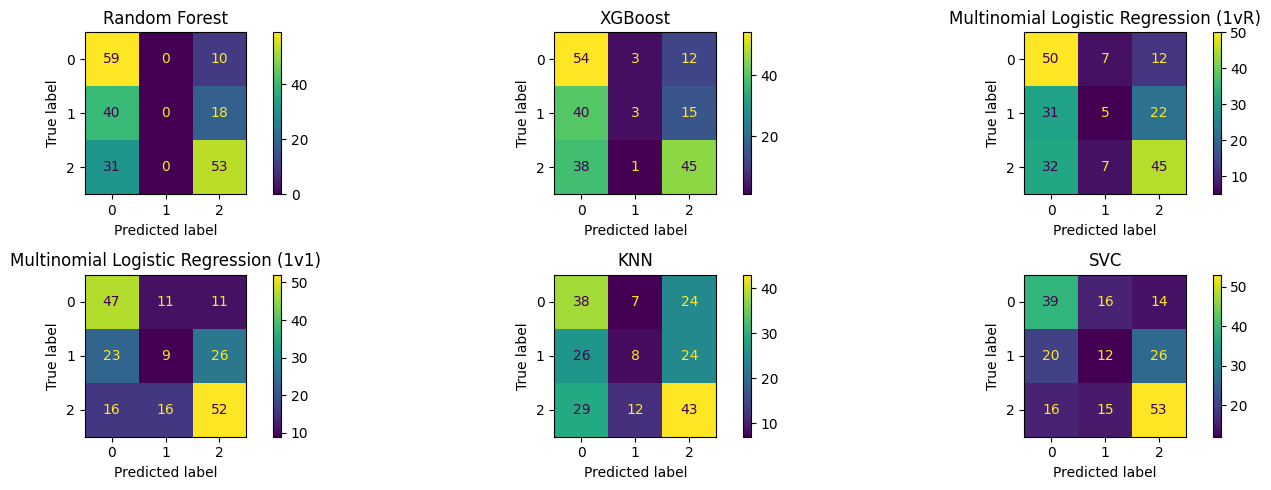

In [149]:
# Confusion matrix for RF
cm_rf = confusion_matrix(y_test_res, y_pred_RF)
disp_rf = ConfusionMatrixDisplay(cm_rf)

# Confusion matrix for XGB
cm_xgb = confusion_matrix(y_test_res, y_pred_XGB)
disp_xgb = ConfusionMatrixDisplay(cm_xgb)

# Confusion matrix for Multinomial Logistic Regression
cm_mc_1vR = confusion_matrix(y_pred_test, y_pred_MC_1vR)
disp_mc_1vR = ConfusionMatrixDisplay(cm_mc_1vR)

cm_mc_1v1 = confusion_matrix(y_pred_test, y_pred_MC_1v1)
disp_mc_1v1 = ConfusionMatrixDisplay(cm_mc_1v1)

# Confusion matrix for KNN
cm_knn = confusion_matrix(y_pred_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(cm_knn)

# Confusion matrix for SVC
cm_svc = confusion_matrix(y_pred_test, y_pred_svc)
disp_svc = ConfusionMatrixDisplay(cm_svc)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 5))

# Plot each confusion matrix
disp_rf.plot(ax=axes[0, 0])
disp_rf.ax_.set_title("Random Forest")

disp_xgb.plot(ax=axes[0, 1])
disp_xgb.ax_.set_title("XGBoost")

disp_mc_1vR.plot(ax=axes[0, 2])
disp_mc_1vR.ax_.set_title("Multinomial Logistic Regression (1vR)")

disp_mc_1v1.plot(ax=axes[1, 0])
disp_mc_1v1.ax_.set_title("Multinomial Logistic Regression (1v1)")

disp_knn.plot(ax=axes[1, 1])
disp_knn.ax_.set_title("KNN")

disp_svc.plot(ax=axes[1, 2])
disp_svc.ax_.set_title("SVC")

plt.tight_layout()
plt.show()


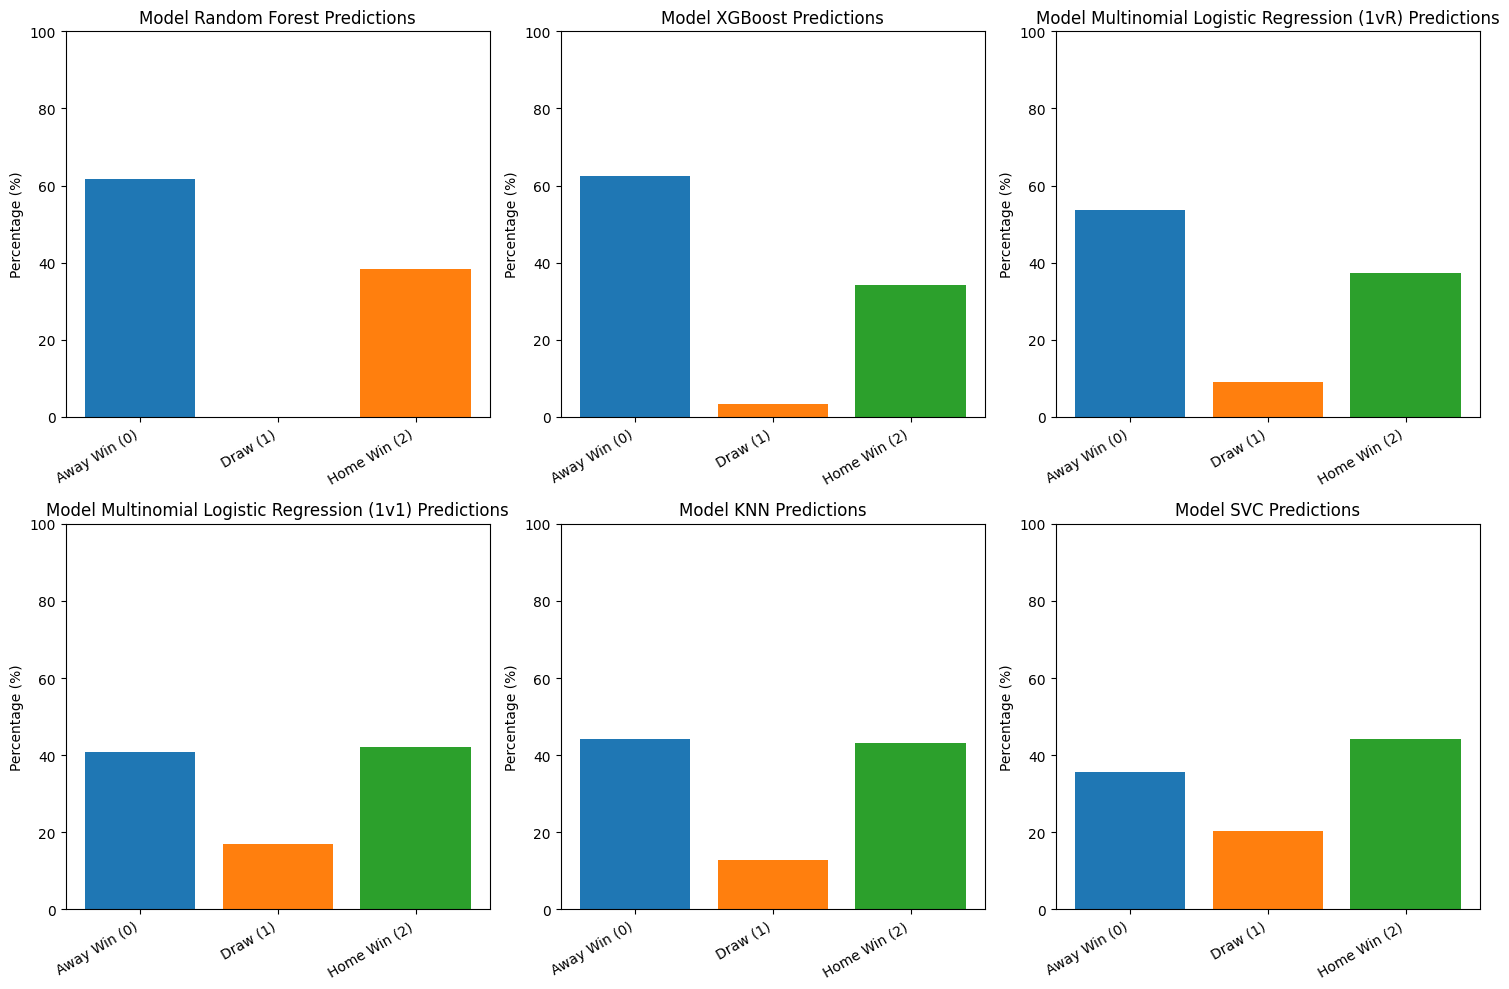

In [150]:
predictions_list = [y_pred_RF, y_pred_XGB, y_pred_MC_1vR, y_pred_MC_1v1, y_pred_knn, y_pred_svc]
models = ['Random Forest', 'XGBoost', 'Multinomial Logistic Regression (1vR)', 'Multinomial Logistic Regression (1v1)', 'KNN', 'SVC']
classes = ['Away Win (0)', 'Draw (1)', 'Home Win (2)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns

for i, ax in enumerate(axes.flat):
    predictions = predictions_list[i]
    
    # Count occurrences of each class
    unique, counts = np.unique(predictions, return_counts=True)
    
    # Convert to percentage
    percentages = counts / counts.sum() * 100
    
    # Plot the bar chart
    ax.bar(unique, percentages, color=colors)
    
    # Formatting
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(classes, rotation=30, ha="right")
    ax.set_ylim(0, 100)
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Model {models[i]} Predictions")

plt.tight_layout()
plt.show()

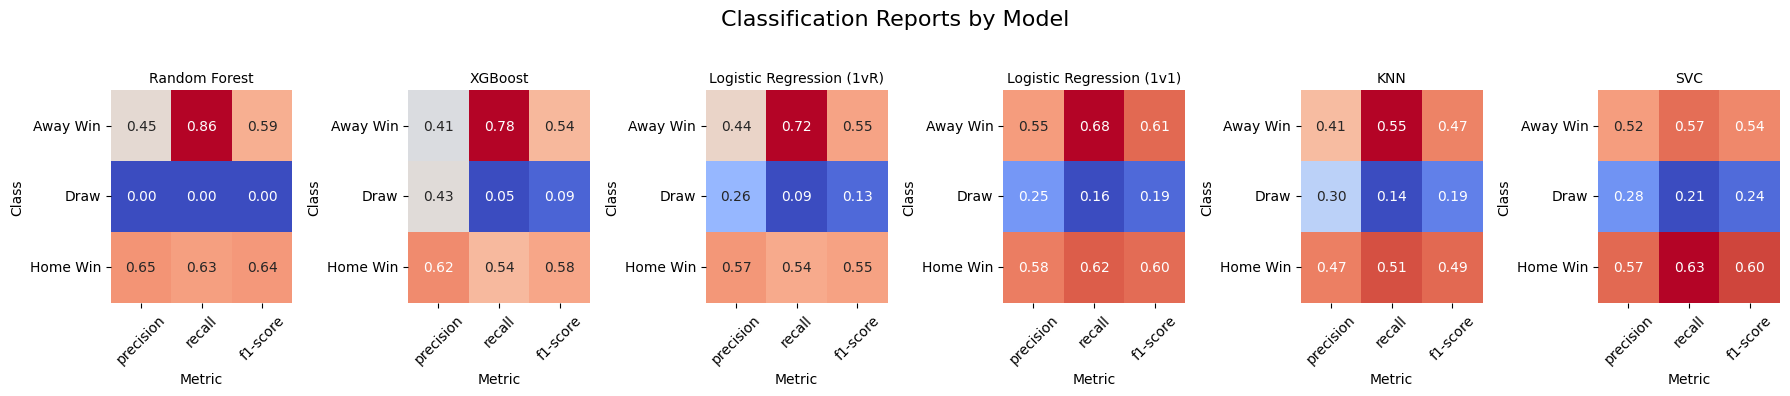

In [151]:
# Create a DataFrame to store the accuracies and the accuracies per class
all_reports = [
    rf_report, xgb_report, mc_1vR_report, mc_1v1_report, knn_report, svc_report
]

models = [
    "Random Forest",
    "XGBoost",
    "Logistic Regression (1vR)",
    "Logistic Regression (1v1)",
    "KNN",
    "SVC"
]

fig, axes = plt.subplots(1, len(models), figsize=(18, 4))
# axes = axes.flatten()

for ax, model_name, report in zip(axes, models, all_reports):
    # Convert report dict to DataFrame and select metrics
    df = pd.DataFrame(report).transpose()
    df = df[["precision", "recall", "f1-score"]]
    
    # Remove 'accuracy', 'macro avg', 'weighted avg' if you only want class-specific rows
    df = df.drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")

    # Plot heatmap
    sns.heatmap(df, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, cbar=False)
    ax.set_title(model_name, fontsize=10)
    ax.set_ylabel("Class")
    ax.set_xlabel("Metric")
    ax.tick_params(axis='x', labelrotation=45)
    ax.tick_params(axis='y', labelrotation=0)

plt.suptitle("Classification Reports by Model", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
plt.show()

In [152]:
f1_df = pd.DataFrame(
    {
        "Model": models,
        "F1 Score (Away Win)": [report["Away Win"]["f1-score"] for report in all_reports],
        "F1 Score (Draw)": [report["Draw"]["f1-score"] for report in all_reports],
        "F1 Score (Home Win)": [report["Home Win"]["f1-score"] for report in all_reports],
        "Overall F1 Score (Avg)": [report["macro avg"]["f1-score"] for report in all_reports],
        "Overall F1 Score (Weighted)": [report["weighted avg"]["f1-score"] for report in all_reports],
    }
).set_index("Model")

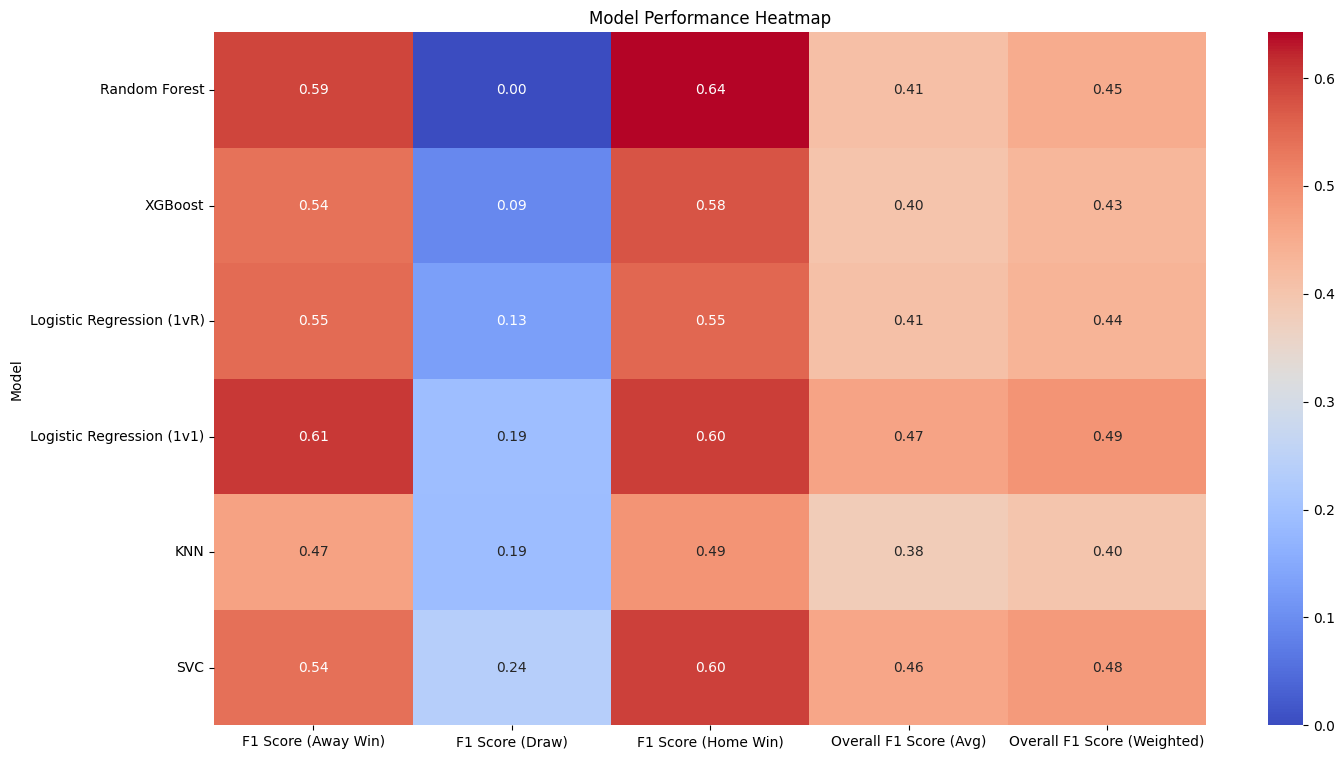

In [153]:
plt.figure(figsize=(16, 9))
sns.heatmap(f1_df, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Model Performance Heatmap")
plt.show()

In [155]:
f1_df

,F1 Score (Away Win),F1 Score (Draw),F1 Score (Home Win),Overall F1 Score (Avg),Overall F1 Score (Weighted)
Model,,,,,
Random Forest,0.592965,0.000000,0.642424,0.411796,0.449660
XGBoost,0.537313,0.092308,0.576923,0.402181,0.430758
Logistic Regression (1vR),0.549451,0.129870,0.552147,0.410489,0.435189
Logistic Regression (1v1),0.606452,0.191489,0.601156,0.466366,0.490278
KNN,0.469136,0.188235,0.491429,0.382933,0.400796
SVC,0.541667,0.237624,0.598870,0.459387,0.480864


In [154]:
print(f"Random Forest:\n{cm_rf}")
print(f"XGB:\n{cm_xgb}")
print(f"Multiclass Regerssion 1vR:\n{cm_mc_1vR}")
print(f"Multiclass Regression 1v1:\n{cm_mc_1v1}")
print(f"KNN:\n{cm_knn}")
print(f"SVC:\n{cm_svc}")

Random Forest:
[[59  0 10]
 [40  0 18]
 [31  0 53]]
XGB:
[[54  3 12]
 [40  3 15]
 [38  1 45]]
Multiclass Regerssion 1vR:
[[50  7 12]
 [31  5 22]
 [32  7 45]]
Multiclass Regression 1v1:
[[47 11 11]
 [23  9 26]
 [16 16 52]]
KNN:
[[38  7 24]
 [26  8 24]
 [29 12 43]]
SVC:
[[39 16 14]
 [20 12 26]
 [16 15 53]]
